# pdf-ingestion-for-rag — end-to-end pipeline demo

This notebook runs the **whole ingestion pipeline** over every PDF in `../samples/`:

```
PDF ─▶ layout-aware parse (PyMuPDF) ─▶ hierarchical chunking ─▶ finalized Chunks
```

For each document it prints high-level stats and a few example chunks, then
aggregates everything into tables and plots (chunks per document, token-count
distribution, pages, content signals, section depth).

The pipeline is deterministic and makes **no embedding calls at ingest time** —
running this cell twice yields identical chunk ids.

## 1. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Make the src/ package importable when running from notebooks/ without an install.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = PROJECT_ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

SAMPLES_DIR = PROJECT_ROOT / "samples"

import pandas as pd
import matplotlib.pyplot as plt

from pdf_ingestion_for_rag import ingest_pdf, IngestionConfig

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Python      : {sys.version.split()[0]}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Samples dir : {SAMPLES_DIR}")

sample_pdfs = sorted(SAMPLES_DIR.glob("*.pdf"))
print(f"\nFound {len(sample_pdfs)} sample PDF(s):")
for p in sample_pdfs:
    print(f"  • {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")

Python      : 3.14.5
Project root: C:\Users\yucho\Documents\06_tools\pdf_ingestion_for_rag
Samples dir : C:\Users\yucho\Documents\06_tools\pdf_ingestion_for_rag\samples

Found 3 sample PDF(s):
  • bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf  (12.6 MB)
  • jpm_Climate-Report-2024.pdf  (0.6 MB)
  • socgen_pillar-3-31122025-en.pdf  (3.1 MB)


## 2. Configuration

`IngestionConfig` is the single source of all tunables. Defaults target
**text-embedding-3-large**: chunks land in a **~200–800 token** band with
100-token overlap.

Headings are **soft boundaries** — a chunk only breaks at a *major* heading
(`split_heading_level`) once it already holds `min_tokens`, so table-heavy PDFs
don't fragment into one-line chunks. `hard_max_tokens` caps every chunk below the
8191-token embedding-request limit (large tables are window-split).

Note: `Chunk.text` is always the **raw** passage. The section breadcrumb is added
at embed time by `Chunk.to_embedding_input()` (on by default), so stored text
stays pristine for display and citation.

In [2]:
config = IngestionConfig(
    max_tokens=800,
    min_tokens=200,
    overlap_tokens=100,
    split_on_section=True,
    split_heading_level=2,     # only H1/H2 are chunk boundaries
    merge_across_sections=True,
    keep_tables_whole=True,
    hard_max_tokens=8000,      # stay under the 8191 embedding limit
    detect_language=False,     # set True if the [lang] extra (langdetect) is installed
)
config.model_dump()

{'tokenizer_encoding': 'cl100k_base',
 'max_tokens': 800,
 'min_tokens': 200,
 'overlap_tokens': 100,
 'hard_max_tokens': 8000,
 'split_on_section': True,
 'split_heading_level': 2,
 'merge_across_sections': True,
 'keep_tables_whole': True,
 'heading_size_ratio': 1.15,
 'heading_max_words': 18,
 'max_heading_levels': 4,
 'extract_tables': True,
 'extract_images': True,
 'detect_language': False,
 'pdf_password': None,
 'skip_pages_on_error': True}

## 3. Run the pipeline over every sample

`ingest_pdf` runs parse → chunk → finalize and returns an `IngestionResult`
(doc id, file hash, page count, the list of `Chunk`s, and any warnings).

In [3]:
import time

results = {}
for pdf_path in sample_pdfs:
    t0 = time.perf_counter()
    result = ingest_pdf(pdf_path, config)
    dt = time.perf_counter() - t0
    results[pdf_path.name] = result

    print(f"══ {pdf_path.name}")
    print(f"   pages        : {result.page_count}")
    print(f"   chunks       : {len(result.chunks)}")
    print(f"   doc_id       : {result.doc_id}")
    print(f"   file_hash    : {result.file_hash[:16]}…")
    print(f"   ingest time  : {dt:.2f}s")
    if result.warnings:
        print(f"   ⚠ warnings   : {result.warnings}")
    print()

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


══ bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf
   pages        : 11
   chunks       : 17
   doc_id       : 31220897-3127-5c9d-9ad3-8fc96dacfca0
   file_hash    : 570c892b0d182b77…
   ingest time  : 2.67s



══ jpm_Climate-Report-2024.pdf
   pages        : 38
   chunks       : 52
   doc_id       : fd9e29d7-f30f-5caa-a627-9262ab5219c1
   file_hash    : 864208a7be0fa777…
   ingest time  : 5.57s



══ socgen_pillar-3-31122025-en.pdf
   pages        : 314
   chunks       : 570
   doc_id       : 4596e2bd-a7e1-53ab-83cb-6c6e93b7ca75
   file_hash    : 8a90755e7d17478a…
   ingest time  : 87.73s



## 4. Peek at example chunks

For each document we show the first content chunk and one chunk that contains a
table (if any) — with its section breadcrumb, page span, and token count.

In [4]:
def show_chunk(chunk, max_chars: int = 500) -> None:
    m = chunk.metadata
    crumb = " > ".join(m.section_path) if m.section_path else "(no section)"
    print(f"  chunk_index : {m.chunk_index} / {m.total_chunks}")
    print(f"  section     : {crumb}")
    print(f"  pages       : {m.page_start}–{m.page_end}")
    print(f"  tokens/chars: {m.token_count} / {m.char_count}")
    print(f"  tables/imgs : {m.contains_tables} / {m.contains_images}")
    print(f"  chunk_id    : {m.chunk_id}")

    def preview(s: str) -> str:
        s = s.strip().replace("\n", "\n    ")
        return s[:max_chars] + ("…" if len(s) > max_chars else "")

    # Stored text is raw; the breadcrumb is added only for the embedder.
    print("  text (raw)  :\n    " + preview(chunk.text))
    print("  embed input :\n    " + preview(chunk.to_embedding_input()))


for name, result in results.items():
    if not result.chunks:
        continue
    print("=" * 90)
    print(name)
    print("=" * 90)
    print("\n— first chunk —")
    show_chunk(result.chunks[0])
    table_chunk = next((c for c in result.chunks if c.metadata.contains_tables), None)
    if table_chunk is not None:
        print("\n— a chunk containing a table —")
        show_chunk(table_chunk)
    print()

bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf

— first chunk —
  chunk_index : 0 / 17
  section     : (no section)
  pages       : 1–3
  tokens/chars: 785 / 4200
  tables/imgs : True / True
  chunk_id    : 1c4a8023-42a3-5386-a329-edf25b8bc051
  text (raw)  :
    BNP PARIBAS SUPPORTING
    
    ITS CLIENTS’ TRANSITION
    
    2025 CSR Achievements
    
    SUMMARY
    
    Introduction......................................................................................................................................................p.4
    
    BNP PARIBAS
    
    Serving Individual Clients......................................................................................................................p.8
    
    SUPPORTING ITS
    
    Serving Co…
  embed input :
    BNP PARIBAS SUPPORTING
    
    ITS CLIENTS’ TRANSITION
    
    2025 CSR Achievements
    
    SUMMARY
    
    Introduction.....................................................................

## 5. Aggregate into a tidy DataFrame

One row per chunk across all documents — the basis for the summary and plots.

In [5]:
rows = []
for name, result in results.items():
    for c in result.chunks:
        m = c.metadata
        rows.append(
            {
                "document": name,
                "chunk_index": m.chunk_index,
                "page_start": m.page_start,
                "page_end": m.page_end,
                "token_count": m.token_count,
                "char_count": m.char_count,
                "section_depth": len(m.section_path),
                "contains_tables": m.contains_tables,
                "contains_images": m.contains_images,
                "section_title": m.section_title,
            }
        )

df = pd.DataFrame(rows)
print(f"Total chunks across all documents: {len(df)}")
df.head(10)

Total chunks across all documents: 639


,document,chunk_index,page_start,page_end,token_count,char_count,section_depth,contains_tables,contains_images,section_title
0,bnpparibas_supporting_clients_transition_2025_...,0,1,3,785,4200,0,True,True,NaN
1,bnpparibas_supporting_clients_transition_2025_...,1,3,3,778,3528,3,True,True,transition to renewed targets for the next 2027-
2,bnpparibas_supporting_clients_transition_2025_...,2,3,4,779,3137,3,False,True,transition to renewed targets for the next 2027-
3,bnpparibas_supporting_clients_transition_2025_...,3,4,5,770,3638,3,False,True,scope decreased by more than 50%
4,bnpparibas_supporting_clients_transition_2025_...,4,5,5,775,3511,3,False,True,serving individual clients
5,bnpparibas_supporting_clients_transition_2025_...,5,5,6,782,3541,3,False,False,Supporting the energy transition of housing
6,bnpparibas_supporting_clients_transition_2025_...,6,6,6,783,3333,3,False,False,"3, developed by Equinor and Polenergia. This is"
7,bnpparibas_supporting_clients_transition_2025_...,7,6,7,776,3577,3,False,True,by ESB and Red Rock Renewables Limited. The
8,bnpparibas_supporting_clients_transition_2025_...,8,7,7,772,3503,3,False,False,Financing sustainable mobilities and their inf...
9,bnpparibas_supporting_clients_transition_2025_...,9,7,8,777,3591,3,False,True,Financing sustainable mobilities and their inf...


In [6]:
# Per-document summary table
summary = (
    df.groupby("document")
    .agg(
        chunks=("chunk_index", "count"),
        pages=("page_end", "max"),
        median_tokens=("token_count", "median"),
        mean_tokens=("token_count", "mean"),
        max_tokens=("token_count", "max"),
        table_chunks=("contains_tables", "sum"),
        image_chunks=("contains_images", "sum"),
    )
    .round(1)
)
summary

,chunks,pages,median_tokens,mean_tokens,max_tokens,table_chunks,image_chunks
document,,,,,,,
bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf,17,11,778.0,773.7,788,3,10
jpm_Climate-Report-2024.pdf,52,38,780.0,724.2,1059,11,2
socgen_pillar-3-31122025-en.pdf,570,314,781.0,839.3,8011,274,3


## 6. Plots

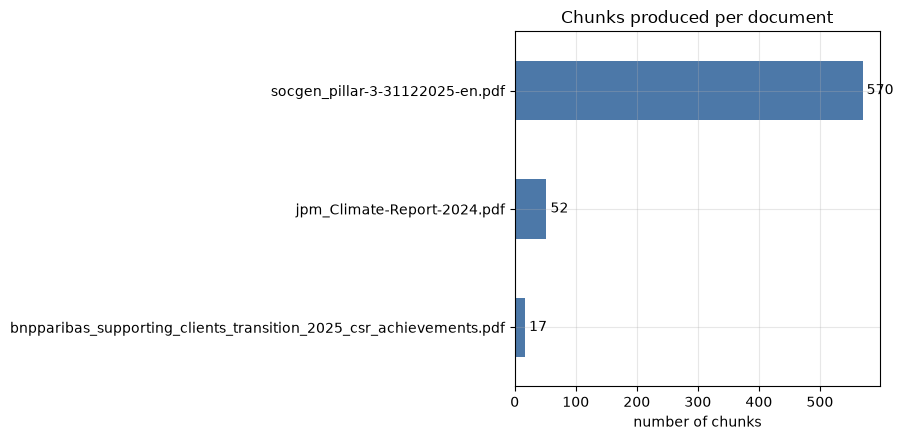

In [7]:
# 6a. Chunks per document
ax = summary["chunks"].sort_values().plot.barh(color="#4C78A8")
ax.set_xlabel("number of chunks")
ax.set_ylabel("")
ax.set_title("Chunks produced per document")
for i, v in enumerate(summary["chunks"].sort_values()):
    ax.text(v, i, f" {int(v)}", va="center")
plt.tight_layout()
plt.show()

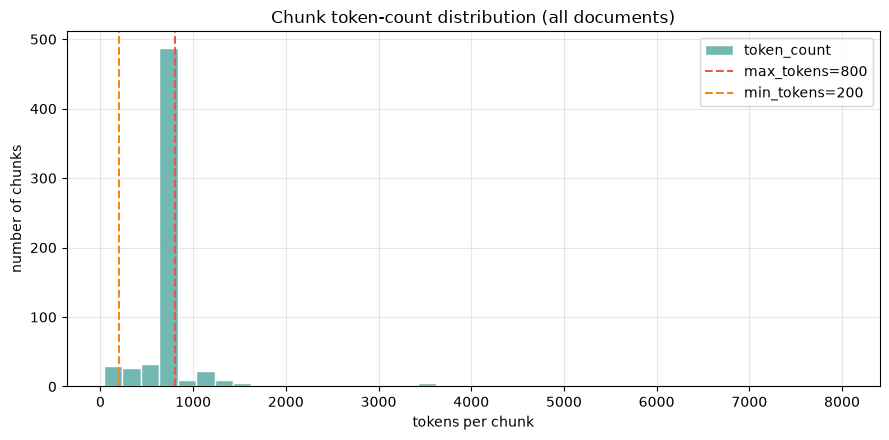

In [8]:
# 6b. Token-count distribution (all chunks), with the max_tokens ceiling marked
ax = df["token_count"].plot.hist(bins=40, color="#72B7B2", edgecolor="white")
ax.axvline(config.max_tokens, color="#E45756", linestyle="--", label=f"max_tokens={config.max_tokens}")
ax.axvline(config.min_tokens, color="#F58518", linestyle="--", label=f"min_tokens={config.min_tokens}")
ax.set_xlabel("tokens per chunk")
ax.set_ylabel("number of chunks")
ax.set_title("Chunk token-count distribution (all documents)")
ax.legend()
plt.tight_layout()
plt.show()

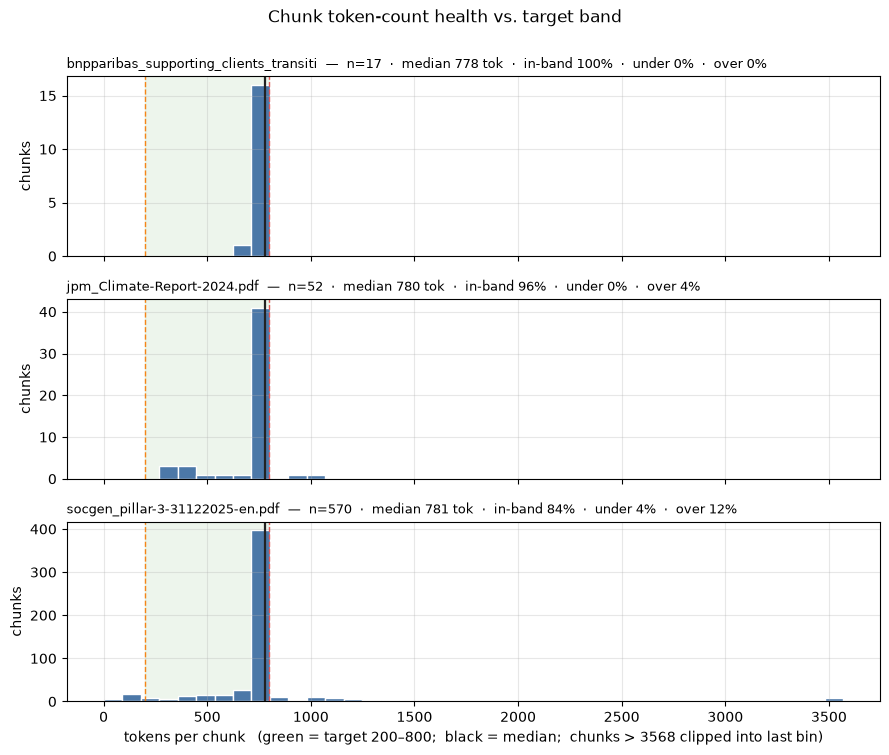

,median_tok,in_band_%,under_min_%,over_max_%,embed_risk_>8191
document,,,,,
socgen_pillar-3-31122025-en.pdf,781.0,83.5,4.4,12.1,0
jpm_Climate-Report-2024.pdf,780.0,96.2,0.0,3.8,0
bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf,778.0,100.0,0.0,0.0,0


In [9]:
# 6b-bis. Token-distribution HEALTH CHECK — one histogram per document with the
# target band [min_tokens, max_tokens] shaded green and the median marked. This
# is the quickest way to eyeball whether chunks land in the retrieval-friendly
# zone or fragment (left) / overflow (right).
import numpy as np

docs = list(summary.index)
lo, hi, cap = config.min_tokens, config.max_tokens, config.hard_max_tokens

# Shared bins; oversized chunks (e.g. whole tables) are clipped into the last bin
# so one giant table can't stretch the x-axis and hide the bulk of the data.
x_max = max(hi * 1.4, float(df["token_count"].quantile(0.99)))
bins = np.linspace(0, x_max, 41)

fig, axes = plt.subplots(len(docs), 1, figsize=(9, 2.5 * len(docs)), sharex=True)
axes = np.atleast_1d(axes)

health_rows = []
for ax, doc in zip(axes, docs):
    tok = df.loc[df["document"] == doc, "token_count"]
    ax.axvspan(lo, hi, color="#54A24B", alpha=0.10, label="target band")
    ax.hist(tok.clip(upper=bins[-1]), bins=bins, color="#4C78A8", edgecolor="white")
    ax.axvline(lo, color="#F58518", linestyle="--", linewidth=1)
    ax.axvline(hi, color="#E45756", linestyle="--", linewidth=1)
    ax.axvline(tok.median(), color="#222222", linewidth=1.6)

    under = float((tok < lo).mean() * 100)
    over = float((tok > hi).mean() * 100)
    in_band = 100 - under - over
    ax.set_title(
        f"{doc[:38]}  —  n={len(tok)}  ·  median {tok.median():.0f} tok  ·  "
        f"in-band {in_band:.0f}%  ·  under {under:.0f}%  ·  over {over:.0f}%",
        fontsize=9, loc="left",
    )
    ax.set_ylabel("chunks")
    health_rows.append({
        "document": doc,
        "median_tok": round(float(tok.median()), 0),
        "in_band_%": round(in_band, 1),
        "under_min_%": round(under, 1),
        "over_max_%": round(over, 1),
        "embed_risk_>8191": int((tok > 8191).sum()),  # must be 0
    })

axes[-1].set_xlabel(
    f"tokens per chunk   (green = target {lo}–{hi};  black = median;  "
    f"chunks > {int(bins[-1])} clipped into last bin)"
)
fig.suptitle("Chunk token-count health vs. target band", y=1.001, fontsize=12)
plt.tight_layout()
plt.show()

# Tabular companion — sort worst-fragmented first; embed_risk must be 0 everywhere.
health = pd.DataFrame(health_rows).set_index("document").sort_values("in_band_%")
health

C:\Users\yucho\AppData\Local\Temp\ipykernel_39208\2174533597.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, tick_labels=short_labels, showmeans=True)


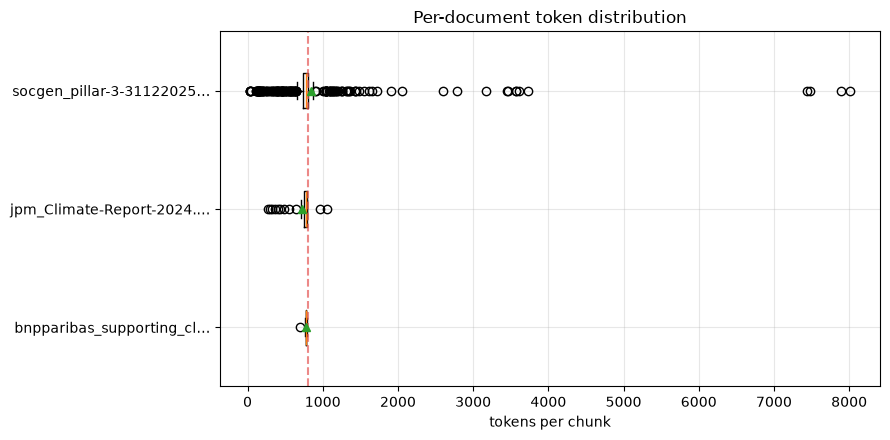

In [10]:
# 6c. Token distribution per document (box plot)
docs = list(summary.index)
data = [df.loc[df["document"] == d, "token_count"] for d in docs]
short_labels = [d[:24] + "…" if len(d) > 25 else d for d in docs]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(data, vert=False, tick_labels=short_labels, showmeans=True)
ax.axvline(config.max_tokens, color="#E45756", linestyle="--", alpha=0.7)
ax.set_xlabel("tokens per chunk")
ax.set_title("Per-document token distribution")
plt.tight_layout()
plt.show()

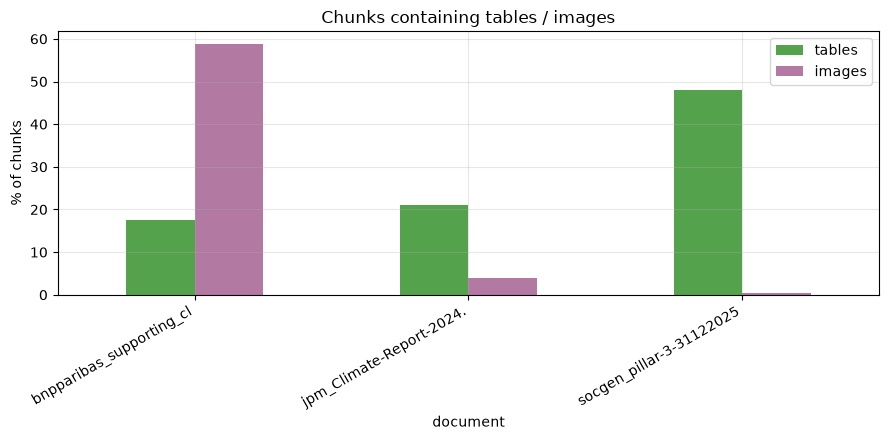

In [11]:
# 6d. Content signals: share of chunks with tables / images per document
signals = summary[["table_chunks", "image_chunks"]].copy()
signals["table_%"] = 100 * summary["table_chunks"] / summary["chunks"]
signals["image_%"] = 100 * summary["image_chunks"] / summary["chunks"]
ax = signals[["table_%", "image_%"]].plot.bar(color=["#54A24B", "#B279A2"])
ax.set_ylabel("% of chunks")
ax.set_title("Chunks containing tables / images")
ax.set_xticklabels([lbl[:24] for lbl in signals.index], rotation=30, ha="right")
ax.legend(["tables", "images"])
plt.tight_layout()
plt.show()

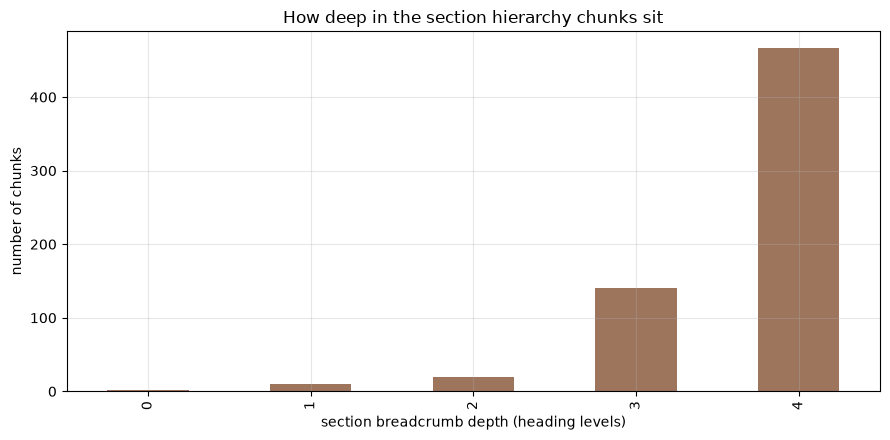

In [12]:
# 6e. Section-depth distribution — how deep the heading hierarchy goes
depth_counts = df["section_depth"].value_counts().sort_index()
ax = depth_counts.plot.bar(color="#9D755D")
ax.set_xlabel("section breadcrumb depth (heading levels)")
ax.set_ylabel("number of chunks")
ax.set_title("How deep in the section hierarchy chunks sit")
plt.tight_layout()
plt.show()

## 7. Determinism check & optional export

Re-ingesting the same bytes must yield identical chunk ids (UUID5 over the file
hash + index). We verify that, then optionally dump all chunks to JSONL — the
same format the CLI produces (`{"text": ..., <all metadata fields>}`).

In [13]:
# Determinism: run the first document again and compare ids
if sample_pdfs:
    first = sample_pdfs[0]
    again = ingest_pdf(first, config)
    ids_a = [c.metadata.chunk_id for c in results[first.name].chunks]
    ids_b = [c.metadata.chunk_id for c in again.chunks]
    print(f"{first.name}: chunk ids identical across runs -> {ids_a == ids_b}")

bnpparibas_supporting_clients_transition_2025_csr_achievements.pdf: chunk ids identical across runs -> True


In [14]:
import json

OUT_DIR = PROJECT_ROOT / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for name, result in results.items():
    out_path = OUT_DIR / (Path(name).stem + ".jsonl")
    with out_path.open("w", encoding="utf-8") as f:
        for c in result.chunks:
            record = {"text": c.text, **c.metadata.model_dump()}
            f.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")
    print(f"wrote {len(result.chunks):>4} chunks -> {out_path.relative_to(PROJECT_ROOT)}")

wrote   17 chunks -> notebooks\out\bnpparibas_supporting_clients_transition_2025_csr_achievements.jsonl
wrote   52 chunks -> notebooks\out\jpm_Climate-Report-2024.jsonl
wrote  570 chunks -> notebooks\out\socgen_pillar-3-31122025-en.jsonl
